### DEEP CTD CAST

In [1]:
# Import packages
import os              # For file path handling
import time            # For sleep during retry logic
import shutil          # For copying downloaded content
import requests        # For HTTP downloads
import urllib3         # For disabling SSL warnings
import numpy as np     # For logical operations and array handling
import pandas as pd    # For reading and manipulating the GDAC index
from datetime import datetime  # For date filtering
import xarray as xr 
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cmocean
import gsw as gsw

In [2]:
os.chdir(r'C:\Users\nribeiro\OneDrive - University of Tasmania\IMOS Shared Docs\CAPSTAN 2025\Datasets\CTD') #Will need to change this 

In [3]:
ds = xr.open_mfdataset(
    "in2026_t02004CtdAvg.nc",
    combine="by_coords"
)


In [4]:
## Calculating
# Extract coordinate arrays
lon0 = ds.longitude.values
lat0 = ds.latitude.values

# Broadcast to full 4D shape of temperature
lon = np.broadcast_to(lon0, ds.temperature.shape)
lat = np.broadcast_to(lat0, ds.temperature.shape)


In [9]:
T  = ds.temperature.values.flatten()
S  = ds.salinity.values.flatten()
O2 = ds.oxygen.values.flatten()
F = ds.fluorometer.values.flatten()

P = np.tile(
    ds.pressure.values,
    int(T.size / ds.pressure.size)
)

lon = lon.flatten()
lat = lat.flatten()

In [11]:
mask = np.isfinite(T) & np.isfinite(S) & np.isfinite(O2) & np.isfinite(P)

T  = T[mask]
S  = S[mask]
F  = F[mask]
O2 = O2[mask]
P  = P[mask]
lon = lon[mask]
lat = lat[mask]


In [12]:
SA = gsw.SA_from_SP(S, P, lon, lat)
CT = gsw.CT_from_t(SA, T, P)
sigma0 = gsw.sigma0(SA, CT)

In [13]:
SA

array([35.68118676, 35.68152626, 35.68149614, ..., 34.87546576,
       34.87554096, 34.87555058])

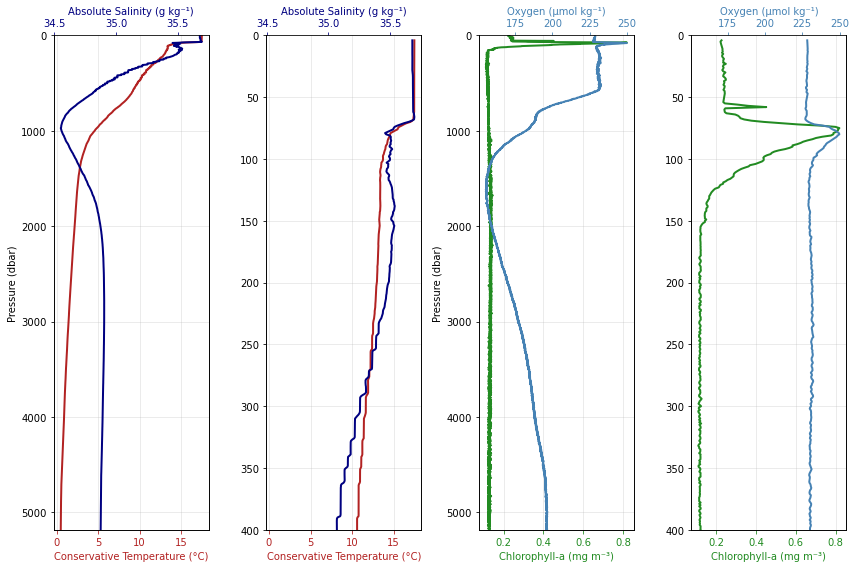

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Assume these are 1‑D arrays of equal length
# CT, SA, F, O2, P

fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(12, 8),
    sharey=False
)

# -------------------------
# Correct axis assignment
# -------------------------
axT_full     = axes[0]
axT_shallow  = axes[1]
axF_full     = axes[2]
axF_shallow  = axes[3]

# Twin x-axes
axS_full     = axT_full.twiny()
axS_shallow  = axT_shallow.twiny()
axO_full     = axF_full.twiny()
axO_shallow  = axF_shallow.twiny()

# -------------------------
# Full depth panels
# -------------------------
axT_full.plot(CT, P, color="firebrick", lw=2)
axS_full.plot(SA, P, color="navy", lw=2)

axF_full.plot(F, P, color="forestgreen", lw=2)
axO_full.plot(O2, P, color="steelblue", lw=2)

# -------------------------
# Shallow panels (0–400 dbar)
# -------------------------
axT_shallow.plot(CT, P, color="firebrick", lw=2)
axS_shallow.plot(SA, P, color="navy", lw=2)

axF_shallow.plot(F, P, color="forestgreen", lw=2)
axO_shallow.plot(O2, P, color="steelblue", lw=2)

# -------------------------
# Formatting
# -------------------------
for ax in [axT_full, axT_shallow, axF_full, axF_shallow]:
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False)

axT_full.set_ylim(np.nanmax(P), 0)
axT_shallow.set_ylim(400, 0)
axF_full.set_ylim(np.nanmax(P), 0)
axF_shallow.set_ylim(400, 0)

# Labels
axT_full.set_xlabel("Conservative Temperature (°C)", color="firebrick")
axS_full.set_xlabel("Absolute Salinity (g kg⁻¹)", color="navy")

axT_shallow.set_xlabel("Conservative Temperature (°C)", color="firebrick")
axS_shallow.set_xlabel("Absolute Salinity (g kg⁻¹)", color="navy")

axF_full.set_xlabel("Chlorophyll‑a (mg m⁻³)", color="forestgreen")
axO_full.set_xlabel("Oxygen (µmol kg⁻¹)", color="steelblue")

axF_shallow.set_xlabel("Chlorophyll‑a (mg m⁻³)", color="forestgreen")
axO_shallow.set_xlabel("Oxygen (µmol kg⁻¹)", color="steelblue")

# Shared y-label
axT_full.set_ylabel("Pressure (dbar)")
axF_full.set_ylabel("Pressure (dbar)")


# Tick colours
for ax, c in zip(
    [axT_full, axT_shallow, axS_full, axS_shallow,
     axF_full, axF_shallow, axO_full, axO_shallow],
    ["firebrick","firebrick","navy","navy",
     "forestgreen","forestgreen","steelblue","steelblue"]
):
    ax.tick_params(axis="x", colors=c)

plt.tight_layout()
plt.show()

In [29]:
### TS PLOT

In [39]:
idx_NADW  = (SA > 34.9) & (CT > 2) & (CT < 4)

In [51]:
## WATER MASS INDEX
idx_STSW  = (CT > 12) & (SA > 35.1)
idx_SABCW = (CT < 12) & (SA < 35.6)
#idx_NWIIW = (O2 < 110) & (P > 600)
idx_AAIW  = (SA < 34.6) & (SA > 34.3) & (CT > 3.5) & (CT < 10)
idx_NADW  = (SA > 34.8) & (CT >= 2) & (CT <= 4)

shallow = P <= 1000

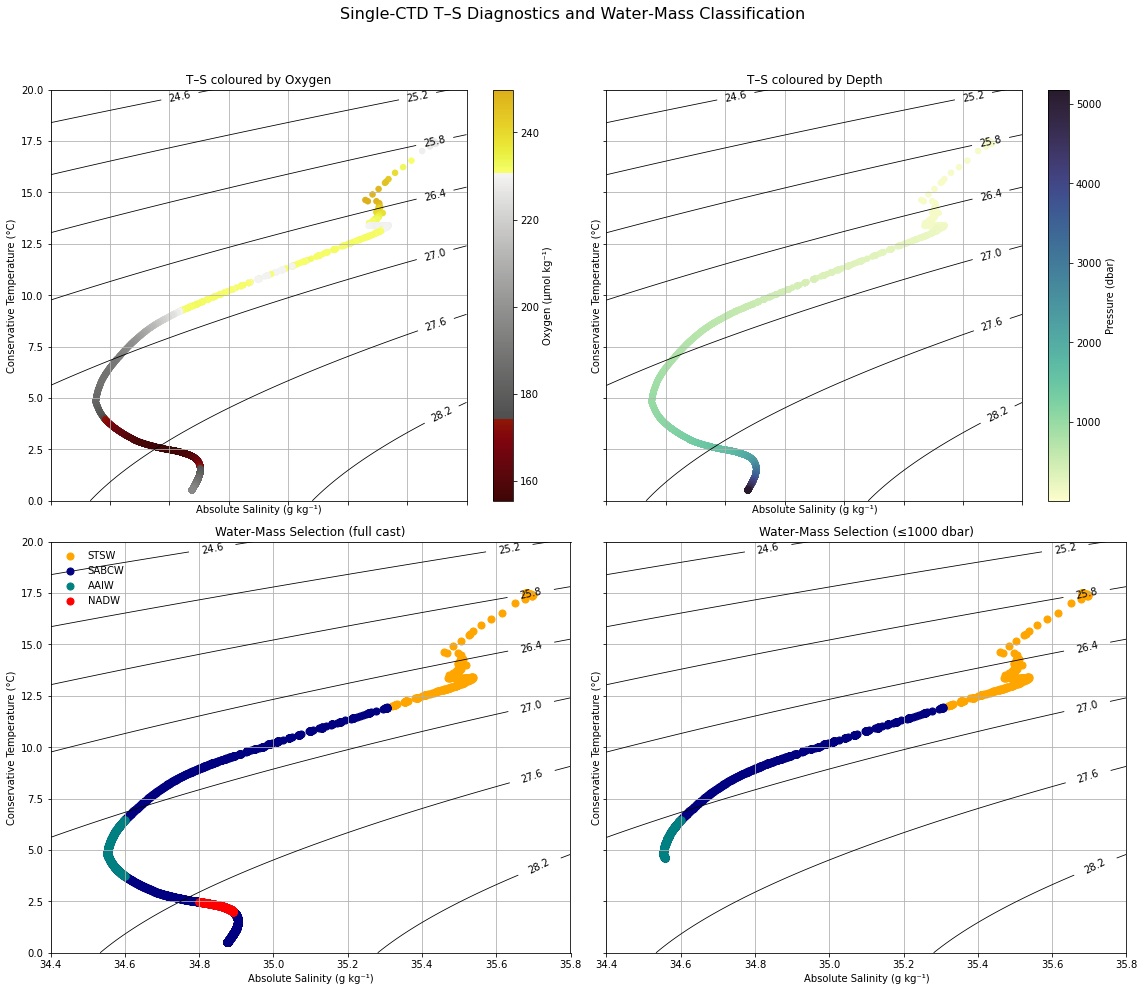

In [52]:
import matplotlib.pyplot as plt
import cmocean
import gsw
import numpy as np

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 14),
    sharex=True,
    sharey=True
)

ax_oxy, ax_depth = axes[0]
ax_wm, ax_wm_shallow = axes[1]

# -------------------------
# Panel 1: TS coloured by oxygen
# -------------------------
sc_oxy = ax_oxy.scatter(
    SA, CT,
    c=O2,
    cmap=cmocean.cm.oxy,
    s=30
)

# -------------------------
# Panel 2: TS coloured by depth
# -------------------------
sc_dep = ax_depth.scatter(
    SA, CT,
    c=P,
    cmap=cmocean.cm.deep,
    s=30
)

# -------------------------
# Panel 3: Water‑mass selection (full cast)
# -------------------------
ax_wm.scatter(SA, CT, s=12, color="lightgrey", alpha=0.5)

ax_wm.scatter(SA[idx_STSW],  CT[idx_STSW],  color="orange", s=50, label="STSW")
ax_wm.scatter(SA[idx_SABCW], CT[idx_SABCW], color="navy",   s=50, label="SABCW")
ax_wm.scatter(SA[idx_AAIW],  CT[idx_AAIW],  color="teal",   s=50, label="AAIW")
ax_wm.scatter(SA[idx_NADW], CT[idx_NADW], color="red",   s=50, label="NADW")

# -------------------------
# Panel 4: Shallow water (≤1000 dbar)
# -------------------------
ax_wm_shallow.scatter(
    SA[shallow], CT[shallow],
    s=12, color="lightgrey", alpha=0.5
)

ax_wm_shallow.scatter(
    SA[idx_STSW & shallow],  CT[idx_STSW & shallow],  color="orange", s=50
)
ax_wm_shallow.scatter(
    SA[idx_SABCW & shallow], CT[idx_SABCW & shallow], color="navy",   s=50
)
ax_wm_shallow.scatter(
    SA[idx_AAIW & shallow],  CT[idx_AAIW & shallow],  color="teal",   s=50
)



ax_wm.set_xlim(34.2, 35.8)
ax_wm.set_ylim(0, 20)


# -------------------------
# Isopycnals (σ₀)
# -------------------------
#SA_g, CT_g = np.meshgrid(
#    np.linspace(SA.min(), SA.max(), 120),
#    np.linspace(CT.min(), CT.max(), 120)
#)
SA_g, CT_g = np.meshgrid(
    np.linspace(34.4, 35.8, 120),
    np.linspace(0, 20, 120)
)


sigma0 = gsw.sigma0(SA_g, CT_g)

for ax in axes.ravel():
    cs = ax.contour(SA_g, CT_g, sigma0, colors="k", linewidths=0.8)
    ax.clabel(cs, fmt="%.1f")
    ax.grid(True)

# -------------------------
# Labels & titles
# -------------------------
ax_oxy.set_title("T–S coloured by Oxygen")
ax_depth.set_title("T–S coloured by Depth")
ax_wm.set_title("Water‑Mass Selection (full cast)")
ax_wm_shallow.set_title("Water‑Mass Selection (≤1000 dbar)")

for ax in axes.ravel():
    ax.set_xlabel("Absolute Salinity (g kg⁻¹)")
    ax.set_ylabel("Conservative Temperature (°C)")

# -------------------------
# Colourbars
# -------------------------
fig.colorbar(sc_oxy, ax=ax_oxy, label="Oxygen (µmol kg⁻¹)")
fig.colorbar(sc_dep, ax=ax_depth, label="Pressure (dbar)")

ax_wm.legend(frameon=False)

fig.suptitle("Single‑CTD T–S Diagnostics and Water‑Mass Classification", fontsize=16)


for ax in axes.ravel():
    ax.set_xlim(34.4, 35.8)
    ax.set_ylim(0, 20)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
